# Pancreas preprocessing QC

Read-only QC for the frozen benchmark-ready object. The actual preprocessing is run by `scripts/preprocess.py`; this notebook **does not create or modify the analysis object**.

In [1]:
from pathlib import Path
import json
import sys

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd

def find_repo_root(start=Path.cwd()):
    start = Path(start).resolve()
    for p in [start, *start.parents]:
        if (p / 'src' / 'scrna_benchmark').is_dir():
            return p
    raise RuntimeError('Run this notebook from inside the repository.')

REPO_ROOT = find_repo_root()
if str(REPO_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / 'src'))
print(REPO_ROOT)

/users/xchen5/scRNA-cross-donor-generalization


In [2]:
DATASET = 'pancreas'
ADATA_PATH = REPO_ROOT / 'data' / DATASET / f'{DATASET}_benchmark_ready.h5ad'
QC_DIR = REPO_ROOT / 'results' / 'preprocessing' / DATASET

adata = ad.read_h5ad(ADATA_PATH)
with open(QC_DIR / 'preprocessing_summary.json') as f:
    summary = json.load(f)

print(adata)
print(json.dumps(summary, indent=2))

AnnData object with n_obs × n_vars = 8500 × 1000
    obs: 'Annotated_Clusters', 'LibraryID', 'nCount_RNA', 'nFeature_RNA', 'percent.mt', 'Seurat_Clusters', 'BMI', 'HbA1c', 'Islet', 'Center', 'Medication', 'Viability', 'Purity', 'Cause_of_death', 'Multiplex', 'BMI_Category', 'Clusters_DiseaseState', 'tissue_ontology_term_id', 'assay_ontology_term_id', 'disease_ontology_term_id', 'cell_type_ontology_term_id', 'self_reported_ethnicity_ontology_term_id', 'development_stage_ontology_term_id', 'sex_ontology_term_id', 'donor_id', 'suspension_type', 'is_primary_data', 'tissue_type', 'cell_type', 'assay', 'disease', 'sex', 'tissue', 'self_reported_ethnicity', 'development_stage', 'observation_joinid', 'batch', 'sample_id', '_scvi_batch', '_scvi_labels'
    var: 'vst.mean', 'vst.variance', 'vst.variance.expected', 'vst.variance.standardized', 'vst.variable', 'feature_is_filtered', 'feature_name', 'feature_reference', 'feature_biotype', 'feature_length', 'feature_type', 'highly_variable', 'means'

## Freeze checks

These assertions make the notebook fail visibly if the refactored preprocessing no longer matches the frozen manuscript population.

In [3]:
assert adata.n_obs == 8500
assert adata.n_vars == 1000
assert adata.obs['donor_id'].astype(str).nunique() == 17
assert adata.obs['cell_type'].astype(str).nunique() == 9
assert adata.obsm['X_pca'].shape == (8500, 15)
assert adata.obsm['X_harmony'].shape == (8500, 15)
assert adata.obsm['X_scVI'].shape == (8500, 15)
assert 'counts' in adata.layers
print('All frozen-population / representation checks passed.')

All frozen-population / representation checks passed.


## Cell-type support before and after filtering

In [4]:
support_before = pd.read_csv(QC_DIR / 'celltype_support_before_filter.csv')
support_final = pd.read_csv(QC_DIR / 'celltype_support_final.csv')
display(support_before)
display(support_final)

,cell_type,n_cells,n_donors,keep_by_cell_count,keep_by_donor_coverage,keep
0,type B pancreatic cell,39484,17,True,True,True
1,pancreatic A cell,25949,17,True,True,True
2,pancreatic ductal cell,7042,17,True,True,True
3,pancreatic D cell,4677,17,True,True,True
4,pancreatic acinar cell,4288,17,True,True,True
5,pancreatic stellate cell,3417,17,True,True,True
6,endothelial cell,1559,17,True,True,True
7,pancreatic PP cell,1288,17,True,True,True
8,leukocyte,470,17,True,True,True
9,mast cell,141,14,False,True,False


,cell_type,n_cells,n_donors,keep_by_cell_count,keep_by_donor_coverage,keep
0,type B pancreatic cell,3750,17,True,True,True
1,pancreatic A cell,2453,17,True,True,True
2,pancreatic ductal cell,730,17,True,True,True
3,pancreatic acinar cell,443,17,True,True,True
4,pancreatic D cell,432,17,True,True,True
5,pancreatic stellate cell,347,17,True,True,True
6,endothelial cell,165,16,False,True,False
7,pancreatic PP cell,131,11,False,True,False
8,leukocyte,49,15,False,True,False


## Final cell counts

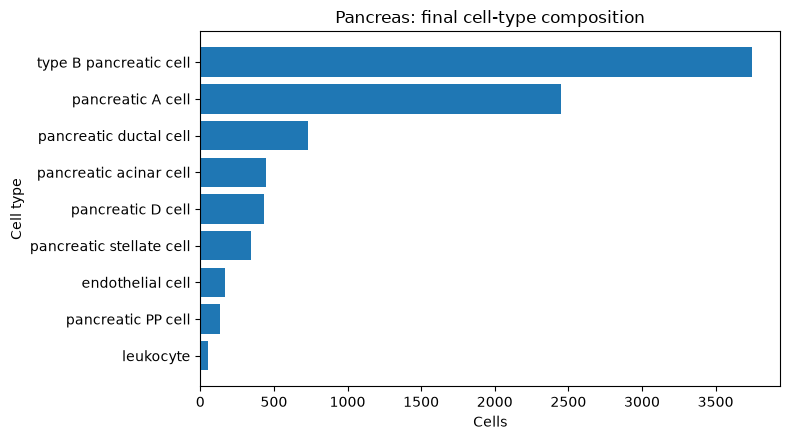

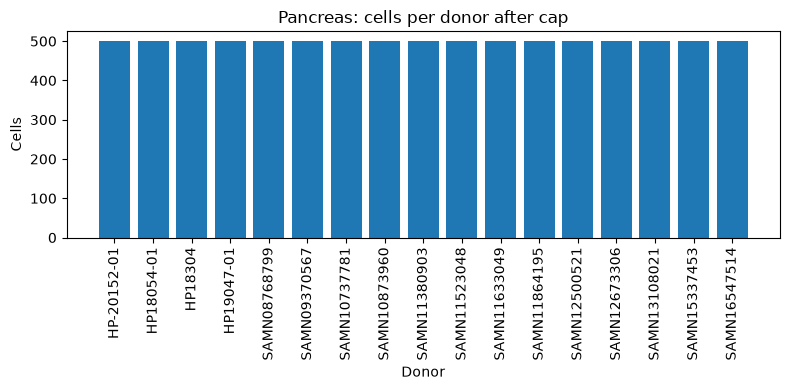

In [5]:
celltype_counts = pd.read_csv(QC_DIR / 'celltype_counts_final.csv')
donor_counts = pd.read_csv(QC_DIR / 'donor_counts_final.csv')

fig, ax = plt.subplots(figsize=(8, 4.5))
plot_df = celltype_counts.sort_values('n_cells')
ax.barh(plot_df.iloc[:, 0], plot_df['n_cells'])
ax.set_xlabel('Cells')
ax.set_ylabel('Cell type')
ax.set_title(f'{DATASET.capitalize()}: final cell-type composition')
fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4))
plot_df = donor_counts.sort_values('n_cells', ascending=False)
ax.bar(plot_df.iloc[:, 0], plot_df['n_cells'])
ax.set_xlabel('Donor')
ax.set_ylabel('Cells')
ax.set_title(f'{DATASET.capitalize()}: cells per donor after cap')
ax.tick_params(axis='x', rotation=90)
fig.tight_layout()
plt.show()

## Donor × cell-type coverage

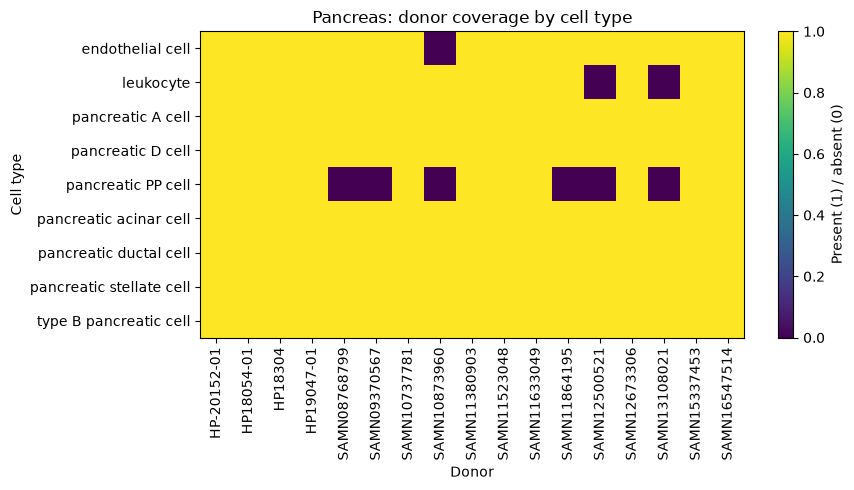

In [6]:
donor_by_type = pd.read_csv(QC_DIR / 'donor_by_celltype_final.csv', index_col=0)
fig, ax = plt.subplots(figsize=(9, 5))
im = ax.imshow((donor_by_type > 0).astype(int).T, aspect='auto', interpolation='nearest')
ax.set_xticks(range(len(donor_by_type.index)))
ax.set_xticklabels(donor_by_type.index, rotation=90)
ax.set_yticks(range(len(donor_by_type.columns)))
ax.set_yticklabels(donor_by_type.columns)
ax.set_xlabel('Donor')
ax.set_ylabel('Cell type')
ax.set_title(f'{DATASET.capitalize()}: donor coverage by cell type')
fig.colorbar(im, ax=ax, label='Present (1) / absent (0)')
fig.tight_layout()
plt.show()

## Provenance

The preprocessing run writes the resolved configuration and software versions alongside the QC tables, so the frozen object can be traced without relying on notebook state.

In [7]:
display(pd.Series(json.load(open(QC_DIR / 'software_versions.json')), name='version').to_frame())
print((QC_DIR / 'resolved_config.yaml').read_text())

,version
numpy,2.5.2
pandas,3.0.5
scipy,1.18.1
anndata,0.13.3.post0
scanpy,1.12.4
harmonypy,2.0.0
scvi-tools,1.5.1
scikit-learn,1.9.0
pyyaml,6.0.3


dataset_name: pancreas
input_path: data/pancreas/pancreas.h5ad
output_path: data/pancreas/pancreas_benchmark_ready.h5ad
qc_output_dir: results/preprocessing/pancreas
celltype_col: cell_type
donor_col: donor_id
filters:
- column: disease
  op: eq
  value: normal
metadata_from_obs:
  batch: Center
  sample_id: LibraryID
support:
  min_cells: 200
  min_donors: 5
downsample:
  group_cols:
  - donor_id
  max_cells_per_group: 500
  random_state: 42
  rng: random_state
gene_filter:
  exclude_var_if_true: []
  min_cells: null
counts:
  source: raw
  target_sum: 10000
  require_integer_like: true
hvg:
  n_top_genes: 1000
  batch_key: donor_id
pca:
  n_comps_compute: 50
  n_comps_keep: 15
  random_state: 42
harmony:
  enabled: true
  batch_key: donor_id
  basis: X_pca
  key_added: X_harmony
  n_comps: 15
  kwargs: {}
scvi:
  enabled: true
  batch_key: donor_id
  layer: counts
  key_added: X_scVI
  n_latent: 15
  max_epochs: null
  early_stopping: true
  random_state: 42
  model_kwargs: {}
  trai